## Zeitreihe_Menden

Collab für uns alle

1. Setup und Daten laden

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [11]:

amazon = pd.read_csv("data/raw/amazon_sales_dataset.csv", low_memory=False, sep=";")
apple   = pd.read_csv("data/raw/apple_stock.csv", header=0, skiprows=[1, 2])
weather = pd.read_csv("data/raw/weather_ts.csv")

datasets = {
    "Amazon Sales": amazon,
    "Apple Stock": apple,
    "Weather": weather
}

for name, df in datasets.items():
    print(name)
    print(df.shape)
    display(df.head())
    print("=" * 150)


Amazon Sales
(50000, 13)


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


Apple Stock
(2596, 6)


,Price,Close,High,Low,Open,Volume
0,2016-01-04,23.730947,23.735454,22.976333,23.113741,270597600
1,2016-01-05,23.136259,23.843569,23.068683,23.821044,223164000
2,2016-01-06,22.683493,23.059675,22.496530,22.651957,273829600
3,2016-01-07,21.726154,22.555105,21.721650,22.228481,324377600
4,2016-01-08,21.841028,22.325334,21.795977,22.199190,283192000


Weather
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


### Stil setzen

**Datenbereinigung**

In [12]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## Amazon Sales plt

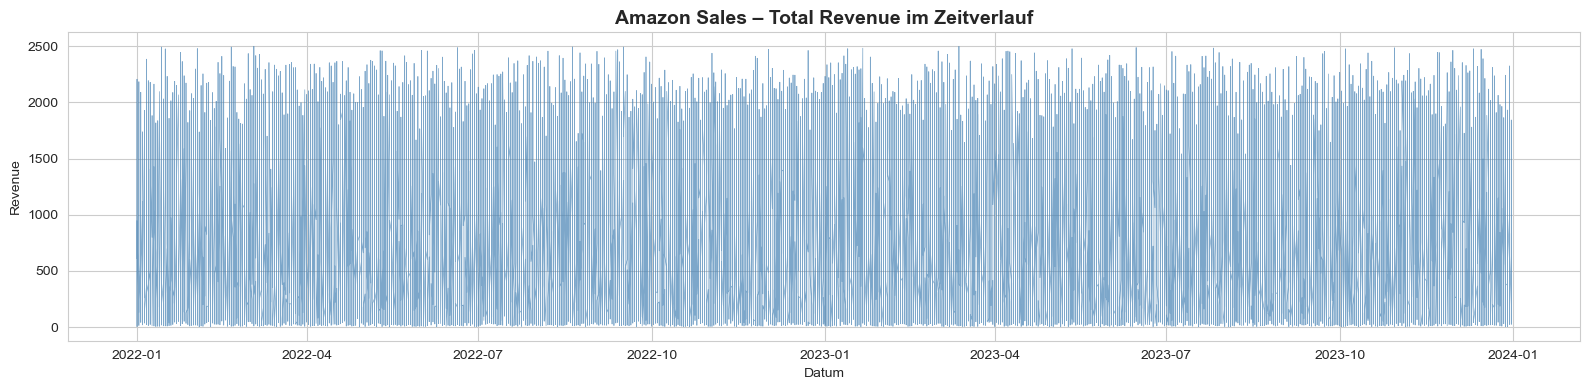

In [13]:
# --- Amazon Sales ---
df_amazon = amazon.copy()
df_amazon["order_date"] = pd.to_datetime(df_amazon["order_date"])
df_amazon = df_amazon.sort_values("order_date")

# 1. Total Revenue über Zeit
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_amazon["order_date"], df_amazon["total_revenue"], 
        color="steelblue", linewidth=0.5, alpha=0.7)
ax.set_title("Amazon Sales – Total Revenue im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Revenue")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()


### Apple Stock plt

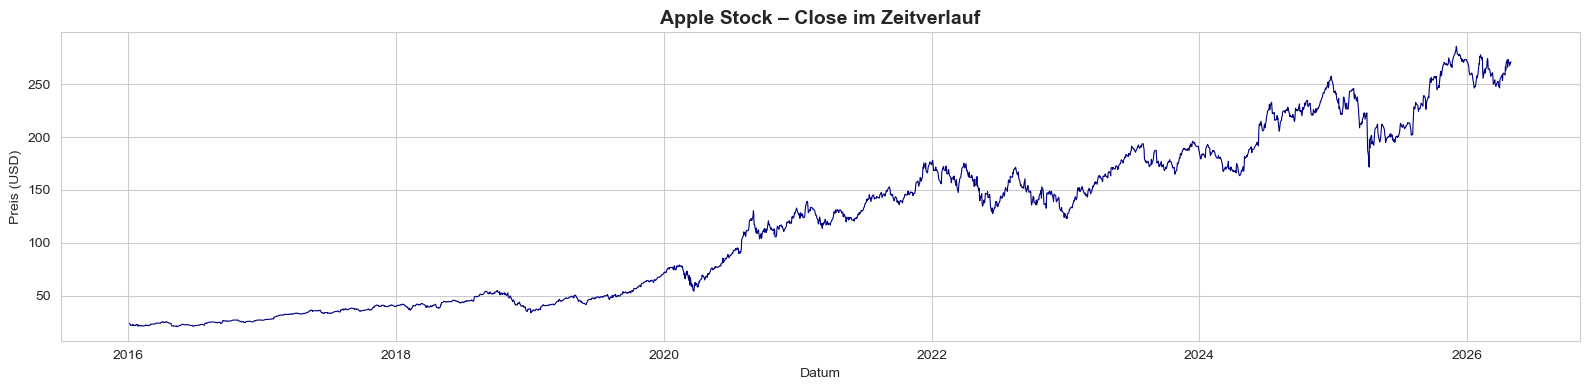

In [14]:
# --- Apple Stock ---
df_apple = apple.copy()
df_apple["Price"] = pd.to_datetime(df_apple["Price"])
df_apple = df_apple.rename(columns={"Price": "Date"}).set_index("Date")

# 5. Close über Zeit
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_apple.index, df_apple["Close"], color="navy", linewidth=0.8)
ax.set_title("Apple Stock – Close im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Preis (USD)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()


### Weather plt

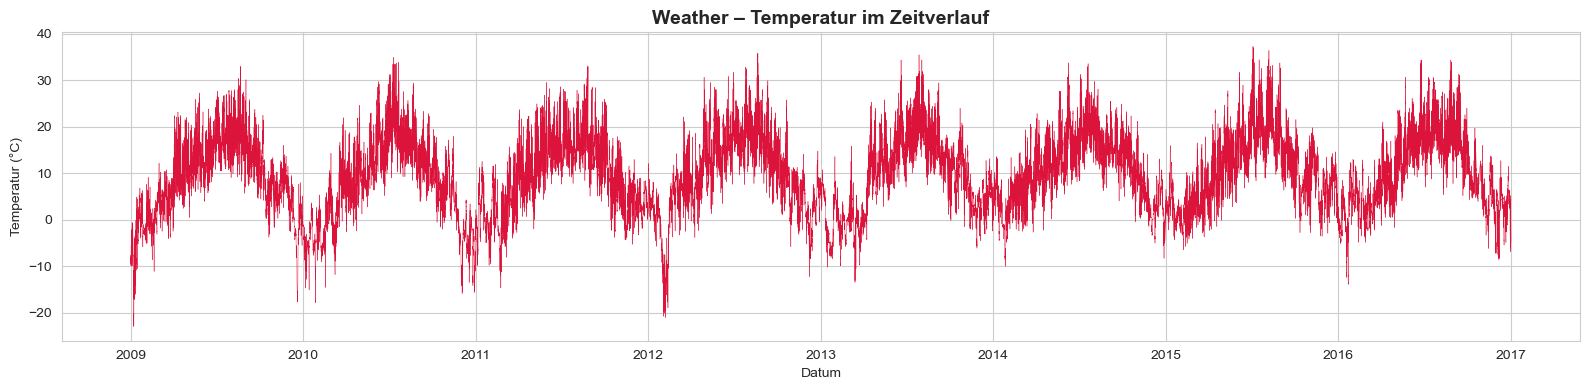

In [15]:
# --- Weather ---
df_weather = weather.copy()
df_weather["Date Time"] = pd.to_datetime(df_weather["Date Time"], format="%d.%m.%Y %H:%M:%S")
df_weather = df_weather.set_index("Date Time")

# 7. Temperatur
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_weather.index, df_weather["T (degC)"], color="crimson", linewidth=0.3)
ax.set_title("Weather – Temperatur im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Temperatur (°C)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()


In [16]:

def remove_outliers_iqr(df, columns):
    """Entfernt Ausreißer anhand der IQR-Methode (1.5 * IQR)."""
    mask = pd.Series(True, index=df.index)
    for col in columns:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask &= (df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)
    return df[mask]
 
amazon["order_date"] = pd.to_datetime(amazon["order_date"])
amazon = amazon.set_index("order_date").sort_index()
amazon = amazon.drop_duplicates()
amazon = amazon.dropna()
amazon = remove_outliers_iqr(amazon, ["total_revenue", "price"])
 
print("Amazon bereinigt:", amazon.shape)
 
 
# ─────────────────────────────────────────────
# 3. APPLE – Aktienkurse bereinigen
# ─────────────────────────────────────────────
 
apple = apple.rename(columns={"Price": "Date"})
apple["Date"] = pd.to_datetime(apple["Date"])
apple = apple.set_index("Date").sort_index()
for col in apple.columns:
    apple[col] = pd.to_numeric(apple[col], errors="coerce")
apple = apple.drop_duplicates()
apple = apple.dropna()
apple = remove_outliers_iqr(apple, ["Close"])
 
print("Apple bereinigt:", apple.shape)
 
 
# ─────────────────────────────────────────────
# 4. WEATHER – Wetterdaten bereinigen
# ─────────────────────────────────────────────
 
weather["Date Time"] = pd.to_datetime(weather["Date Time"], dayfirst=True)
weather = weather.set_index("Date Time").sort_index()
weather = weather.drop_duplicates()
weather = weather.dropna()
weather = weather[weather["wv (m/s)"] >= 0]
weather = weather[weather["max. wv (m/s)"] >= 0]
weather = remove_outliers_iqr(weather, ["T (degC)"])
 
print("Weather bereinigt:", weather.shape)
 
 
# ─────────────────────────────────────────────
# 5. WACHSTUMSRATEN berechnen
# (Menden Skript, Folie 15/16: Wachstumsraten)
# gt = (xt - xt-1) / xt-1
# ─────────────────────────────────────────────
 
amazon_daily = amazon["total_revenue"].resample("D").sum()
amazon["revenue_growth"] = amazon_daily.pct_change()
 
apple["close_growth"] = apple["Close"].pct_change()
 
weather["temp_diff"] = weather["T (degC)"].diff()
 
 
# ─────────────────────────────────────────────
# 6. ÜBERBLICK
# ─────────────────────────────────────────────
 
datasets_clean = {
    "Amazon Sales": amazon,
    "Apple Stock":  apple,
    "Weather":      weather,
}
 
for name, df in datasets_clean.items():
    print(f"\n{'─' * 45}")
    print(f" {name}")
    print(f"   Shape:       {df.shape}")
    print(f"   Zeitraum:    {df.index.min()}  →  {df.index.max()}")
    print(f"   NaN gesamt:  {df.isnull().sum().sum()}")
    print(f"   Dtype Index: {df.index.dtype}")

Amazon bereinigt: (49248, 12)
Apple bereinigt: (2596, 5)
Weather bereinigt: (418665, 14)

─────────────────────────────────────────────
 Amazon Sales
   Shape:       (49248, 13)
   Zeitraum:    2022-01-01 00:00:00  →  2023-12-31 00:00:00
   NaN gesamt:  66
   Dtype Index: datetime64[ns]

─────────────────────────────────────────────
 Apple Stock
   Shape:       (2596, 6)
   Zeitraum:    2016-01-04 00:00:00  →  2026-04-30 00:00:00
   NaN gesamt:  1
   Dtype Index: datetime64[ns]

─────────────────────────────────────────────
 Weather
   Shape:       (418665, 15)
   Zeitraum:    2009-01-01 00:10:00  →  2017-01-01 00:00:00
   NaN gesamt:  1
   Dtype Index: datetime64[ns]


# Deskripitive Analyse

## Amazon 


Statistik:
       total_revenue
count     730.000000
mean    42737.454438
std      6613.714312
min     27837.550000
25%     37967.730000
50%     42516.035000
75%     47209.212500
max     63224.280000

Zeitraum:
2022-01-01 00:00:00 → 2023-12-31 00:00:00

NaN Werte:
total_revenue    0
dtype: int64


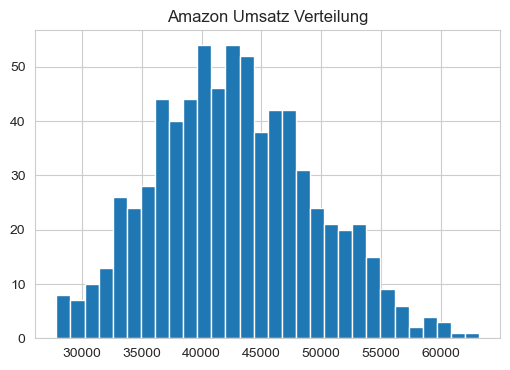

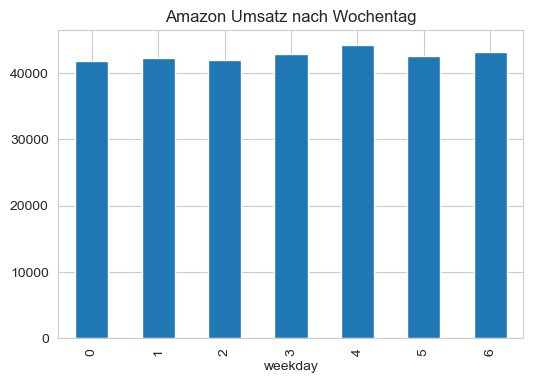

In [18]:

# AMAZON → täglicher Umsatz
amazon_daily = amazon["total_revenue"].resample("D").sum().to_frame()

print("\nStatistik:")
print(amazon_daily.describe())

print("\nZeitraum:")
print(amazon_daily.index.min(), "→", amazon_daily.index.max())

print("\nNaN Werte:")
print(amazon_daily.isnull().sum())


# Histogramm
plt.figure(figsize=(6,4))
plt.hist(amazon_daily["total_revenue"].dropna(), bins=30)
plt.title("Amazon Umsatz Verteilung")
plt.show()

# Wochentage
amazon_daily["weekday"] = amazon_daily.index.dayofweek
plt.figure(figsize=(6,4))
amazon_daily.groupby("weekday")["total_revenue"].mean().plot(kind="bar")
plt.title("Amazon Umsatz nach Wochentag")
plt.show()



Statistik:
             Close
count  2596.000000
mean    118.832186
std      76.584117
min      20.584814
25%      41.935802
50%     123.907543
75%     175.758690
max     285.922455

Zeitraum:
2016-01-04 00:00:00 → 2026-04-30 00:00:00

NaN Werte:
Close    1174
dtype: int64


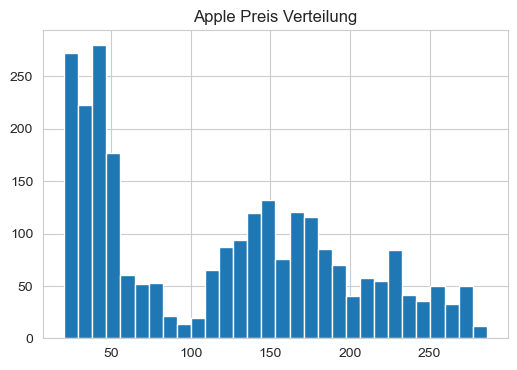

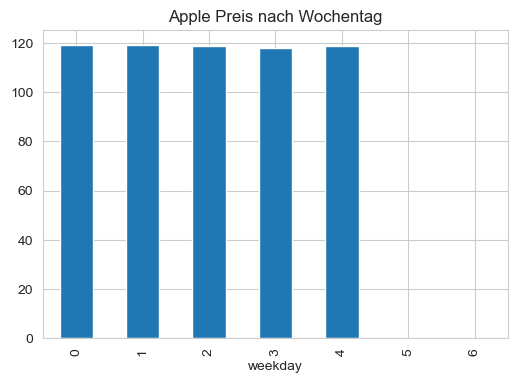

In [20]:
# APPLE → täglicher Schlusskurs
apple_daily = apple["Close"].resample("D").mean().to_frame()

print("\nStatistik:")
print(apple_daily.describe())

print("\nZeitraum:")
print(apple_daily.index.min(), "→", apple_daily.index.max())

print("\nNaN Werte:")
print(apple_daily.isnull().sum())


plt.figure(figsize=(6,4))
plt.hist(apple_daily["Close"].dropna(), bins=30)
plt.title("Apple Preis Verteilung")
plt.show()

apple_daily["weekday"] = apple_daily.index.dayofweek
plt.figure(figsize=(6,4))
apple_daily.groupby("weekday")["Close"].mean().plot(kind="bar")
plt.title("Apple Preis nach Wochentag")
plt.show()


Statistik:
          T (degC)
count  2920.000000
mean      9.453875
std       7.767782
min     -13.646623
25%       3.812344
50%       9.712882
75%      15.427639
max      26.892778

Zeitraum:
2009-01-01 00:00:00 → 2017-01-01 00:00:00

NaN Werte:
T (degC)    3
dtype: int64


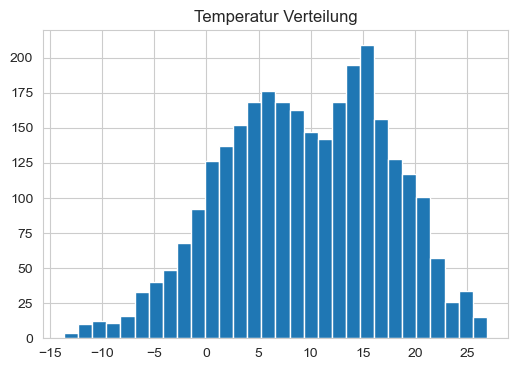

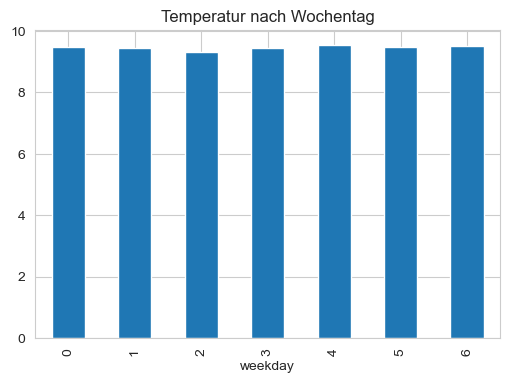

In [21]:
# WEATHER → tägliche Durchschnittstemperatur
weather_daily = weather["T (degC)"].resample("D").mean().to_frame()

print("\nStatistik:")
print(weather_daily.describe())

print("\nZeitraum:")
print(weather_daily.index.min(), "→", weather_daily.index.max())

print("\nNaN Werte:")
print(weather_daily.isnull().sum())

plt.figure(figsize=(6,4))
plt.hist(weather_daily["T (degC)"].dropna(), bins=30)
plt.title("Temperatur Verteilung")
plt.show()

weather_daily["weekday"] = weather_daily.index.dayofweek
plt.figure(figsize=(6,4))
weather_daily.groupby("weekday")["T (degC)"].mean().plot(kind="bar")
plt.title("Temperatur nach Wochentag")
plt.show()